# YOLO26 车辆检测模型训练
基于 UA-DETRAC 数据集进行迁移学习

In [1]:
# 检查环境
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'显存: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')

PyTorch: 2.8.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
显存: 8.0 GB


In [2]:
# 开始训练（极速版 ~1-2小时）
from ultralytics import YOLO
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

model = YOLO('C:/Users/ql157/yolo26n.pt')

results = model.train(
    data='E:/dev/yjwlYOLO/dev/dataset/data.yaml',
    epochs=15,            # 减少轮数
    imgsz=480,            # 缩小图片，提速30%
    batch=32,             # 加大batch，充分利用GPU
    device=0,
    workers=2,
    cache='disk',         # 缓存加速
    freeze=10,            # 冻结前10层（骨干网络），只训练检测头
    project='E:/dev/yjwlYOLO/dev/runs',
    name='train',
    exist_ok=True,
    patience=5,
)

New https://pypi.org/project/ultralytics/8.4.66 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.48  Python-3.13.5 torch-2.8.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:/dev/yjwlYOLO/dev/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=480, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=C:/Users/ql157/yolo26n.pt, momentum=0.937

In [3]:
# 查看训练结果路径
import os
train_dir = 'E:/dev/yjwlYOLO/dev/runs/train'
print('训练完成！')
print(f'最佳权重: {train_dir}/weights/best.pt')
print(f'最终权重: {train_dir}/weights/last.pt')
print(f'\n训练目录下的文件：')
for f in os.listdir(train_dir):
    print(f'  {f}')

训练完成！
最佳权重: E:/dev/yjwlYOLO/dev/runs/train/weights/best.pt
最终权重: E:/dev/yjwlYOLO/dev/runs/train/weights/last.pt

训练目录下的文件：
  args.yaml
  BoxF1_curve.png
  BoxPR_curve.png
  BoxP_curve.png
  BoxR_curve.png
  confusion_matrix.png
  confusion_matrix_normalized.png
  labels.jpg
  results.csv
  results.png
  train_batch0.jpg
  train_batch1.jpg
  train_batch10620.jpg
  train_batch10621.jpg
  train_batch10622.jpg
  train_batch2.jpg
  val_batch0_labels.jpg
  val_batch0_pred.jpg
  val_batch1_labels.jpg
  val_batch1_pred.jpg
  val_batch2_labels.jpg
  val_batch2_pred.jpg
  weights


---
## 模型评估：在验证集上计算各项指标

In [7]:
from ultralytics import YOLO

model = YOLO('E:/dev/yjwlYOLO/dev/runs/train/weights/best.pt')

metrics = model.val(
    data='E:/dev/yjwlYOLO/dev/dataset/data.yaml',
    device=0,
    split='val'
)

print('='*50)
print('模型评估结果')
print('='*50)
print(f'mAP@0.5:     {metrics.box.map50:.4f}')
print(f'mAP@0.5:0.95: {metrics.box.map:.4f}')
print(f'Precision:   {metrics.box.mp:.4f}')
print(f'Recall:      {metrics.box.mr:.4f}')
print('='*50)

print('\n各类别 AP@0.5:')
all_names = list(model.names.values())
for i, cls_idx in enumerate(metrics.box.ap_class_index):
    print(f'  {all_names[cls_idx]}: {metrics.box.ap50[i]:.4f}')

Ultralytics 8.4.48  Python-3.13.5 torch-2.8.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO26n summary (fused): 122 layers, 2,375,811 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.30.0 ms, read: 11.32.9 MB/s, size: 64.9 KB)
val: Scanning E:\dev\yjwlYOLO\dev\dataset\val\labels.cache... 14128 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 14128/14128 4.9Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 883/883 14.5it/s 1:01<0.1ss
                   all      14128     102487      0.765      0.642      0.723      0.542
                   car      14047      87651      0.854        0.8      0.859      0.609
                   bus       2419       2419      0.818      0.708      0.832      0.668
                   van       7296      11750       0.75      0.656      0.722      0.534
                others        666        667      0.636      0.403       0.48      0.359
Speed: 0

---
## 速度测试：FPS 测量

In [8]:
import time
from ultralytics import YOLO

model = YOLO('E:/dev/yjwlYOLO/dev/runs/train/weights/best.pt')

test_img = 'E:/dev/yjwlYOLO/数据集和权重/UA-DETRAC(车辆检测数据集8250车辆)/DETRAC-test-data/Insight-MVT_Annotation_Test/MVI_39051/img00288.jpg'

# 预热
for _ in range(10):
    model.predict(test_img, verbose=False)

# 正式测试
times = []
for _ in range(100):
    start = time.time()
    model.predict(test_img, verbose=False)
    times.append(time.time() - start)

avg_time = sum(times) / len(times)
fps = 1.0 / avg_time

print('='*50)
print('速度测试结果')
print('='*50)
print(f'平均推理时间: {avg_time*1000:.1f} ms')
print(f'FPS: {fps:.1f} 帧/秒')
print(f'是否实时: {"是" if fps >= 30 else "否"} (>=30 FPS为实时)')
print('='*50)

速度测试结果
平均推理时间: 13.4 ms
FPS: 74.4 帧/秒
是否实时: 是 (>=30 FPS为实时)


---
## 检测效果可视化

In [9]:
from ultralytics import YOLO
import os

model = YOLO('E:/dev/yjwlYOLO/dev/runs/train/weights/best.pt')

test_dir = 'E:/dev/yjwlYOLO/数据集和权重/UA-DETRAC(车辆检测数据集8250车辆)/DETRAC-test-data/Insight-MVT_Annotation_Test/MVI_39051'
test_images = [os.path.join(test_dir, f'img{i:05d}.jpg') for i in [100, 300, 500, 700]]

results = model.predict(
    test_images,
    save=True,
    project='E:/dev/yjwlYOLO/dev/runs',
    name='test_images'
)

for r in results:
    print(f'图片: {os.path.basename(r.path)}')
    print(f'  检测到 {len(r.boxes)} 个目标')
    for box in r.boxes:
        cls = r.names[int(box.cls)]
        conf = float(box.conf)
        print(f'    {cls}: {conf:.2%}')
    print()

print('检测结果图片保存在: E:/dev/yjwlYOLO/dev/runs/test_images/')


0: 288x480 3 cars, 14.6ms
1: 288x480 3 cars, 14.6ms
2: 288x480 4 cars, 1 bus, 14.6ms
3: 288x480 3 cars, 1 bus, 14.6ms
Speed: 0.7ms preprocess, 14.6ms inference, 0.3ms postprocess per image at shape (1, 3, 288, 480)
Results saved to E:\dev\yjwlYOLO\dev\runs\test_images
图片: image0.jpg
  检测到 3 个目标
    car: 90.17%
    car: 89.53%
    car: 87.47%

图片: image1.jpg
  检测到 3 个目标
    car: 92.49%
    car: 88.89%
    car: 37.24%

图片: image2.jpg
  检测到 5 个目标
    car: 91.94%
    car: 91.74%
    car: 87.34%
    car: 44.05%
    bus: 25.72%

图片: image3.jpg
  检测到 4 个目标
    car: 93.60%
    car: 90.14%
    bus: 81.68%
    car: 37.15%

检测结果图片保存在: E:/dev/yjwlYOLO/dev/runs/test_images/


---
## 查看训练曲线和混淆矩阵

训练曲线:


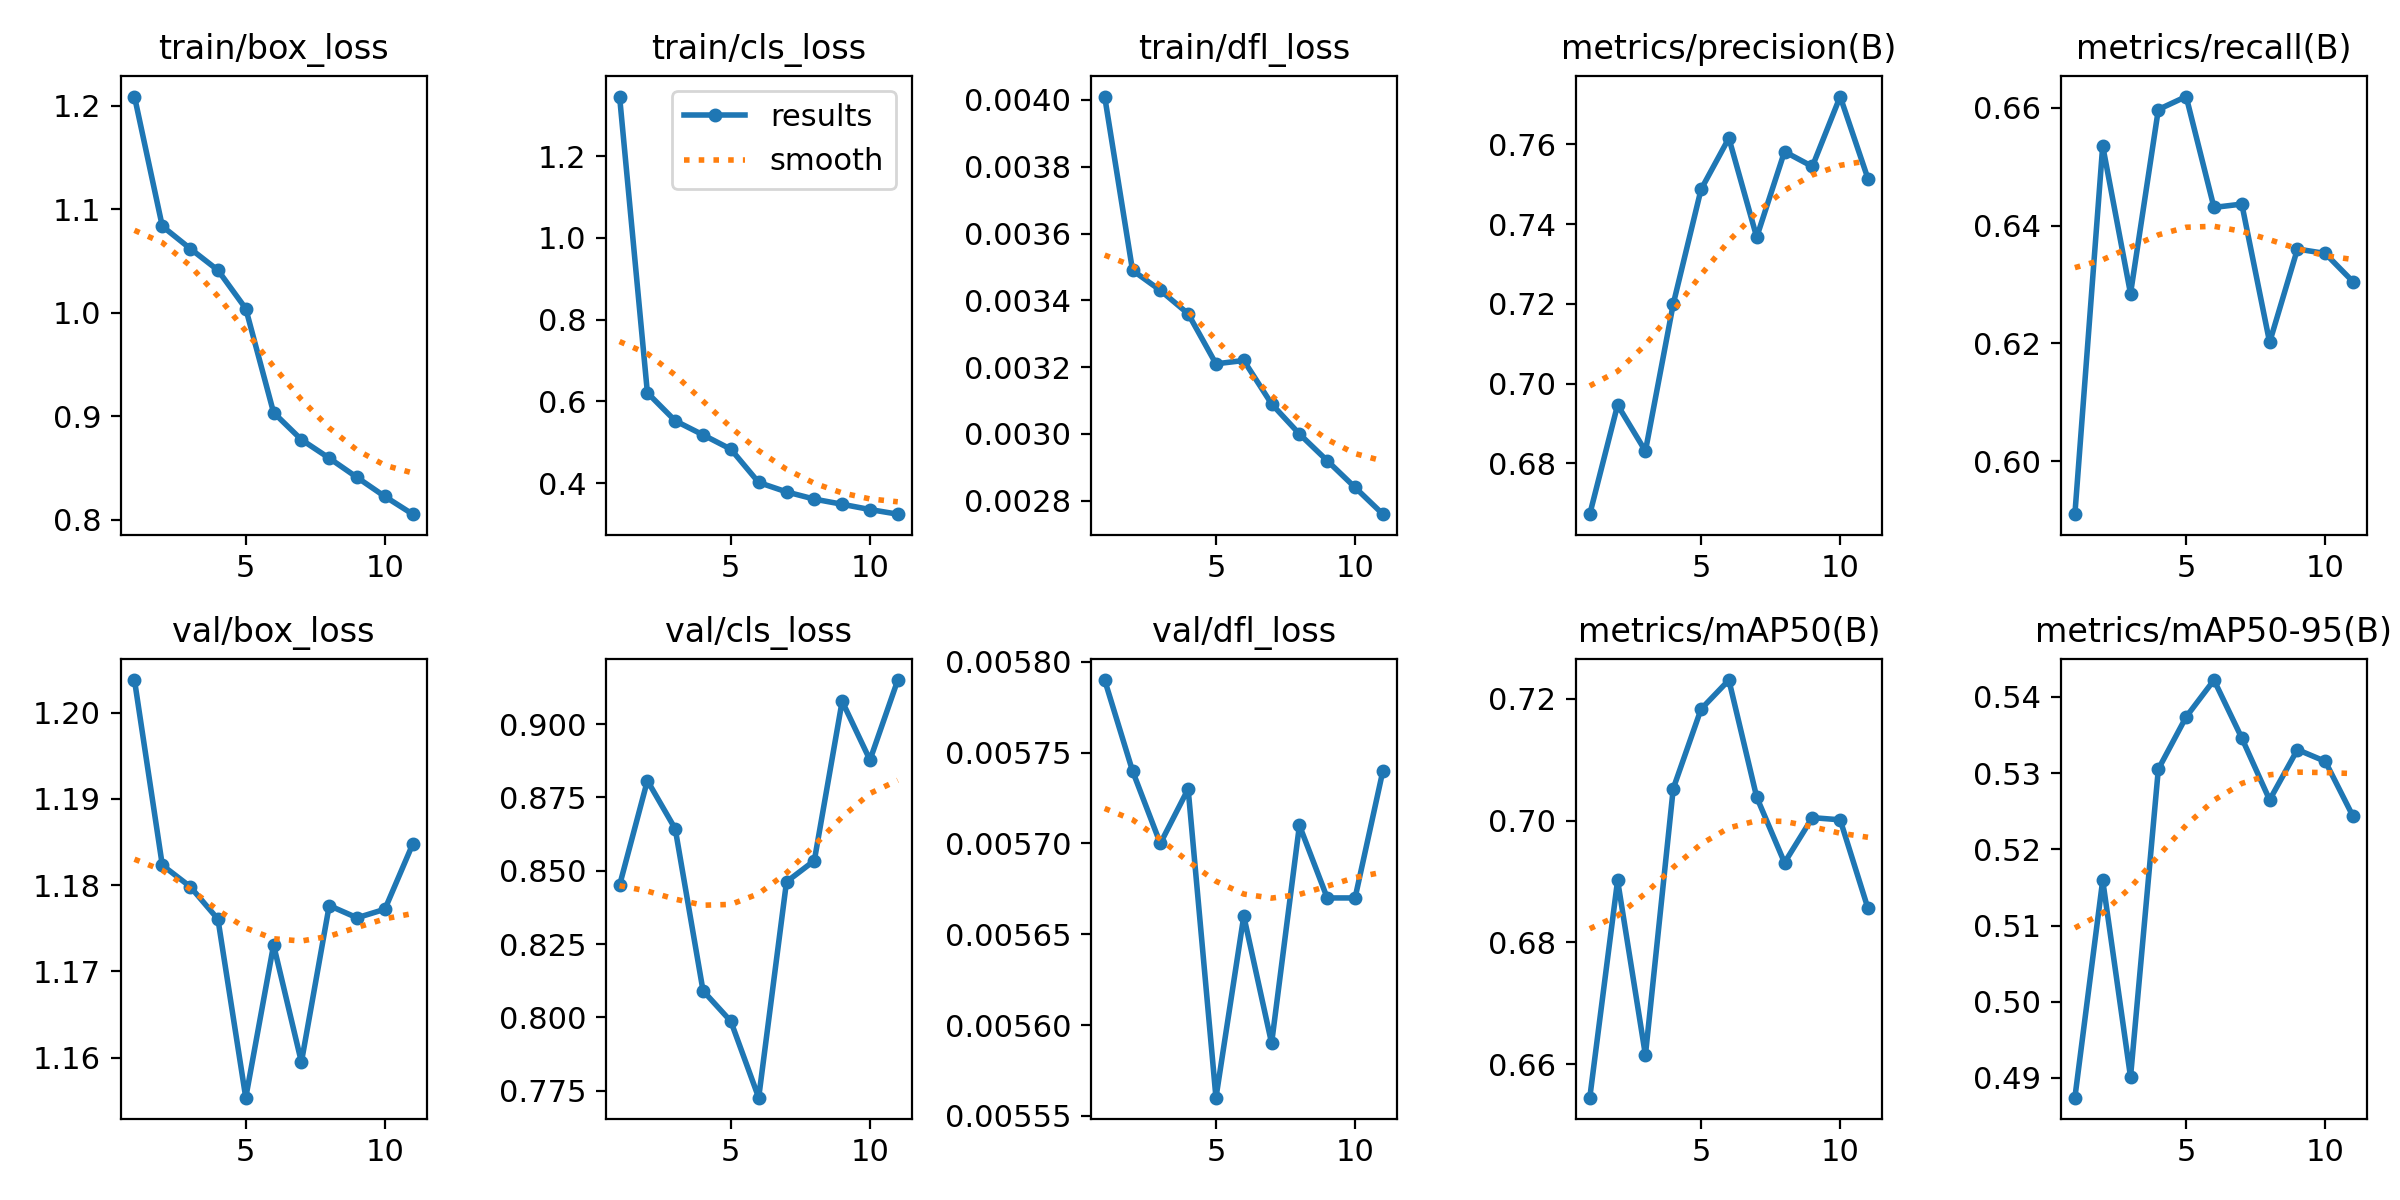


混淆矩阵:


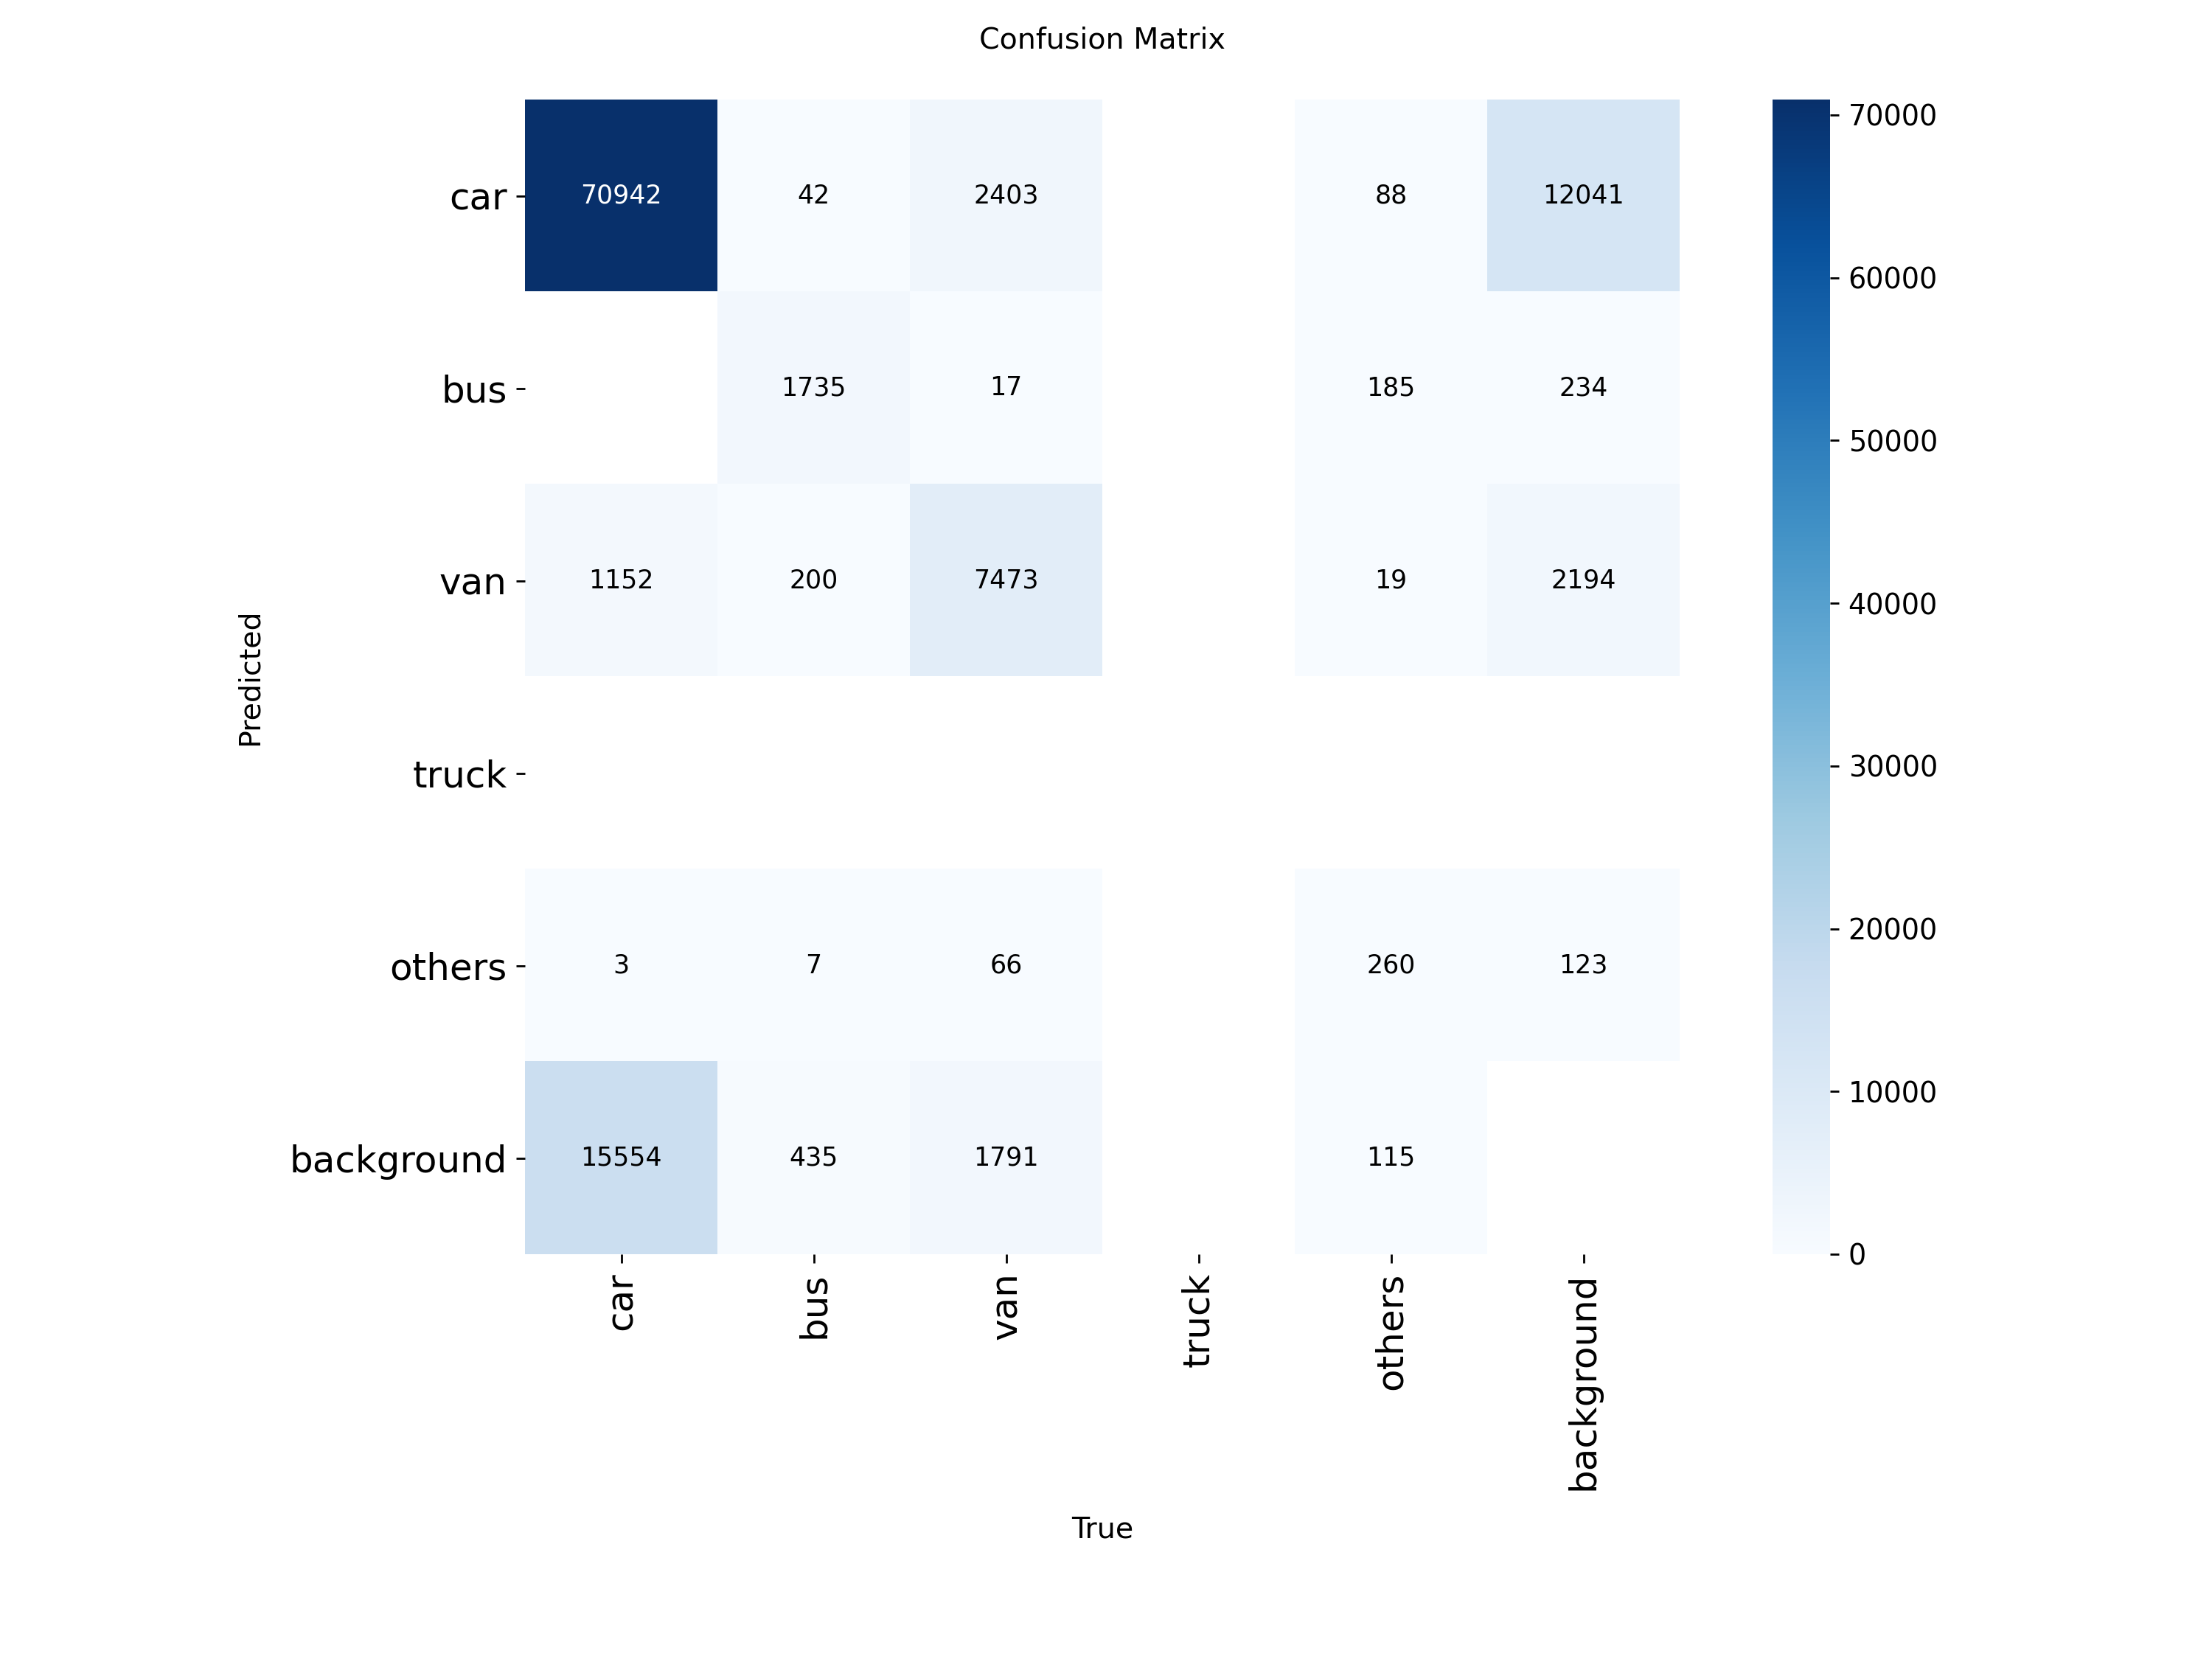

In [10]:
from IPython.display import display, Image
import os

train_dir = 'E:/dev/yjwlYOLO/dev/runs/train'

if os.path.exists(f'{train_dir}/results.png'):
    print('训练曲线:')
    display(Image(f'{train_dir}/results.png', width=800))

if os.path.exists(f'{train_dir}/confusion_matrix.png'):
    print('\n混淆矩阵:')
    display(Image(f'{train_dir}/confusion_matrix.png', width=600))

if os.path.exists(f'{train_dir}/PR_curve.png'):
    print('\nPR曲线:')
    display(Image(f'{train_dir}/PR_curve.png', width=600))